# NB04b — Analytical Rigor Repair (post-adversarial-review)

**Project**: `ibd_phage_targeting` — Pillar 2 rigor repair, before NB05
**Depends on**: NB01b (synonymy + ecotype assignments), NB04 (within-ecotype DA + Tier-A candidate list)

## Why this notebook exists

After committing NB04 we ran **two reviews** in parallel: the standard `/berdl-review` and a deliberately adversarial reviewer (a separately-spawned `Agent` with explicit "find flaws" framing). The standard reviewer concluded "no critical issues." The adversarial reviewer identified **5 critical + 6 important issues**, several of which materially undermine NB04's headline claims if left unaddressed:

- **C1 — Feature leakage**: NB04 ran within-ecotype DA on the same taxa used to define the ecotypes. This is selection-on-outcome confounding; within-ecotype effect sizes are mechanically inflated for ecotype-defining species.
- **C2 — Verdict logic**: NB04's H2c "RESOLVED" call hard-coded `pooled CD↑ + within-ecotype n.s. → RESOLVED`. Treating n.s. as positive evidence in finite samples is selective reporting.
- **C3 — Confounders**: no study/cohort/age/medication adjustment. Vujkovic-Cvijin 2020 cited but not implemented.
- **C4 — Jaccard null**: Jaccard = 0.14 reported as supporting H2b without any null distribution. Random-overlap baseline is ~0.05; 0.14 is only 3× baseline.
- **I1 — Single-method DA**: plan H2a falsification criterion required ≥ 2/3 methods agreeing (ANCOM-BC + MaAsLin2 + LinDA). NB04 ran only CLR + Mann-Whitney.
- **I3 — No bootstrap CIs**: no inference on within-ecotype effect sizes beyond p-values + FDR.

This notebook addresses each tractable critical/important issue. Where a full fix would require redoing Pillar 1 (defining ecotypes on pathways instead of taxa, the only complete C1 fix), we substitute a sensitivity analysis that bounds the leakage.

## Sections

| § | Repair | Issue addressed |
|---|---|---|
| 1 | Bootstrap CIs on within-ecotype CLR-Δ for the curated battery (1000 resamples × 14 species × 2 ecotypes) | C2, I3 |
| 2 | Held-out-species sensitivity test (5 random 50/50 splits; refit ecotypes on half, test on held-out half) | C1 (broad bound) |
| 3 | Leave-one-species-out refit + DA for the 14 curated species | C1 (rigorous on H2c claim) |
| 4 | Permutation null for the E1↔E3 top-30 Jaccard (1000 permutations within diagnosis) | C4 |
| 5 | Sub-study extraction from sample IDs + LME confounder adjustment via `statsmodels.mixedlm` | C3 (partial; cMD doesn't expose per-study labels) |
| 6 | ANCOM-BC2 via `rpy2` (alternative compositional DA method) | I1 (partial — adds 1 of 3 plan-mandated methods) |
| 7 | Bootstrap stability of ecotype assignments (subsample 80 % → refit → ARI) | C5 (within-data robustness; external validation still pending) |
| 8 | Revised verdicts: H2c per-species TOST equivalence; H2b Jaccard p-value; refined Tier-A list (bootstrap-stable + study-adjusted + non-leakage-suspect) | All |

After this notebook executes, REPORT.md will be revised to retract overclaims. The stopping rule for proceeding to NB05 is in §8.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import re, json, subprocess
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data')
FIG_OUT = Path('../figures')
RANDOM_STATE = 42
K_REF = 4


## 0. Reload and rebuild the same matrix as NB04 (no methodology drift)

In [2]:
# Synonymy + canonical wide matrix (identical pipeline to NB01b/NB02/NB04)
syn = pd.read_csv(DATA_OUT / 'species_synonymy.tsv', sep='\t')
lookup = dict(zip(syn.alias, syn.canonical))

ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta = ta[(ta.classification_method == 'metaphlan3') & (ta.study_id.isin(['CMD_HEALTHY','CMD_IBD']))].copy()

def normalize_format(name):
    if not isinstance(name, str): return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_',' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

def resolve(name):
    if not isinstance(name, str): return None
    if name in lookup: return lookup[name]
    fn = normalize_format(name)
    return lookup.get(fn, fn) if fn else None

ta['species'] = ta['taxon_name_original'].map(resolve)
ta = ta.dropna(subset=['species']).copy()
wide = ta.pivot_table(index='species', columns='sample_id', values='relative_abundance',
                     aggfunc='sum', fill_value=0.0)

eco = pd.read_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t')
eco_map = dict(zip(eco.sample_id, eco.consensus_ecotype))
diag_map = dict(zip(eco.sample_id, eco.diagnosis))

cols_keep = [c for c in wide.columns if c in eco_map]
wide = wide[cols_keep]

# 5%-prevalence filter (same as NB04)
keep = pd.concat([
    (wide[[c for c in wide.columns if diag_map.get(c) == d]] > 0).mean(axis=1)
    for d in ['HC','CD','UC'] if any(diag_map.get(c) == d for c in wide.columns)
], axis=1).max(axis=1) >= 0.05
w = wide.loc[keep].copy()
print(f'Wide matrix: {w.shape[0]:,} species × {w.shape[1]:,} samples')

cd_ids = [c for c in w.columns if diag_map.get(c) == 'CD']
hc_ids = [c for c in w.columns if diag_map.get(c) == 'HC']
print(f'CD: {len(cd_ids):,}; HC: {len(hc_ids):,}')

# Per-ecotype CD/HC sample IDs
ecotype_cd_ids = {k: [s for s in cd_ids if eco_map.get(s) == k] for k in [1, 3]}
ecotype_hc_ids = {k: [s for s in hc_ids if eco_map.get(s) == k] for k in [1, 3]}
for k in [1, 3]:
    print(f'  E{k}: CD={len(ecotype_cd_ids[k])}, HC={len(ecotype_hc_ids[k])}')

# CLR transform helper (same as NB00, NB01b, NB04)
def clr(M):
    M = M.astype(float).copy()
    col_min_nz = np.where(M > 0, M, np.nan)
    col_min_nz = np.nanmin(col_min_nz, axis=0)
    col_min_nz = np.where(np.isnan(col_min_nz), 1e-6, col_min_nz / 2)
    M = np.where(M > 0, M, col_min_nz[None, :])
    logM = np.log(M)
    return logM - logM.mean(axis=0, keepdims=True)


Wide matrix: 335 species × 8,489 samples
CD: 1,206; HC: 5,333
  E1: CD=581, HC=759
  E3: CD=605, HC=114


In [3]:
# Curated battery for H2c repair — same names as NB04
PROTECTIVE = ['Clostridium scindens','Faecalibacterium prausnitzii','Akkermansia muciniphila',
              'Roseburia intestinalis','Roseburia hominis','Lachnospira eligens',
              'Agathobacter rectalis','Coprococcus eutactus']
PATHOBIONT = ['Mediterraneibacter gnavus','Enterocloster bolteae','Eggerthella lenta',
              'Bilophila wadsworthia','Escherichia coli','Klebsiella oxytoca','Hungatella hathewayi']
BATTERY = PROTECTIVE + PATHOBIONT

# Six engraftment-confirmed pathobionts from the preliminary report (donor 2708 → P1 → P2)
ENGRAFTED = ['Mediterraneibacter gnavus','Enterocloster bolteae','Escherichia coli',
             'Eggerthella lenta','Hungatella hathewayi','Klebsiella oxytoca']


## 1. Bootstrap CIs on within-ecotype CLR-Δ (curated battery)

Repair for **C2** + **I3**. Per species per ecotype: 1000 bootstrap resamples (resample CD column IDs with replacement and HC column IDs with replacement, recompute CLR-Δ as (mean CD-CLR − mean HC-CLR) for that species). Report point estimate + 95 % percentile CI.

Decision rule (replacing NB04's hard-coded n.s.→RESOLVED logic):
- **Equivalent to zero (TOST-style)**: 95 % CI ⊂ [−0.3, +0.3] → "consistent with no within-ecotype effect"
- **Definitively non-zero**: CI excludes zero
- **Indeterminate**: CI includes zero but exits the equivalence region


In [4]:
def bootstrap_clr_delta(w, sp, group_a_ids, group_b_ids, n_boot=1000, rng_seed=42):
    """Per-species bootstrap CI on (mean CLR_a − mean CLR_b).
    CLR is computed over the FULL species matrix (multi-species reference), then we extract
    the row for `sp`. This is the only mathematically correct way — CLR on a 1-species
    submatrix collapses to zero (log(x) - mean(log({x})) = 0) for every entry."""
    if sp not in w.index: return None
    rng = np.random.default_rng(rng_seed)
    cols = [c for c in group_a_ids + group_b_ids if c in w.columns]
    if not cols: return None
    full_clr = clr(w[cols].values)  # species × samples, full multi-species reference
    sp_row_idx = list(w.index).index(sp)
    sp_clr = full_clr[sp_row_idx]
    n_a = len([c for c in group_a_ids if c in w.columns])
    a_clr = sp_clr[:n_a]
    b_clr = sp_clr[n_a:]
    deltas = np.empty(n_boot)
    for i in range(n_boot):
        ai = rng.integers(0, n_a, n_a)
        bi = rng.integers(0, len(b_clr), len(b_clr))
        deltas[i] = a_clr[ai].mean() - b_clr[bi].mean()
    point = a_clr.mean() - b_clr.mean()
    ci_lo, ci_hi = np.percentile(deltas, [2.5, 97.5])
    return {'point': point, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'boot_mean': deltas.mean(), 'boot_sd': deltas.std()}

def equivalence_verdict(ci_lo, ci_hi, eq_lo=-0.3, eq_hi=0.3):
    if ci_lo >= eq_lo and ci_hi <= eq_hi: return 'EQUIV'    # consistent with no effect
    if ci_lo > 0:  return 'CD↑'                              # definitively positive
    if ci_hi < 0:  return 'CD↓'                              # definitively negative
    return 'INDET'                                            # CI spans zero but exits eq region


In [5]:
# Run bootstrap on the 14 curated species in E1 and E3 + pooled
boot_results = []
for sp in BATTERY:
    for ecotype, cd_e, hc_e in [
        ('pooled', cd_ids, hc_ids),
        ('E1', ecotype_cd_ids[1], ecotype_hc_ids[1]),
        ('E3', ecotype_cd_ids[3], ecotype_hc_ids[3]),
    ]:
        if sp not in w.index:
            boot_results.append({'species': sp, 'ecotype': ecotype, 'point': None,
                                 'ci_lo': None, 'ci_hi': None, 'verdict': 'NA'})
            continue
        if min(len(cd_e), len(hc_e)) < 20:
            continue
        r = bootstrap_clr_delta(w, sp, cd_e, hc_e, n_boot=1000)
        verdict = equivalence_verdict(r['ci_lo'], r['ci_hi']) if r else 'NA'
        boot_results.append({'species': sp, 'ecotype': ecotype, 'expected':
                             ('protective' if sp in PROTECTIVE else 'pathobiont'),
                             'point': round(r['point'], 3),
                             'ci_lo': round(r['ci_lo'], 3),
                             'ci_hi': round(r['ci_hi'], 3),
                             'verdict': verdict})
boot_df = pd.DataFrame(boot_results)
boot_df.to_csv(DATA_OUT / 'nb04b_battery_bootstrap_ci.tsv', sep='\t', index=False)
print(boot_df.to_string(index=False))


                     species ecotype   expected  point  ci_lo  ci_hi verdict
        Clostridium scindens  pooled protective  0.977  0.891  1.070     CD↑
        Clostridium scindens      E1 protective -0.125 -0.304  0.042   INDET
        Clostridium scindens      E3 protective  0.177  0.027  0.342     CD↑
Faecalibacterium prausnitzii  pooled protective -1.475 -1.665 -1.284     CD↓
Faecalibacterium prausnitzii      E1 protective  0.515  0.218  0.824     CD↑
Faecalibacterium prausnitzii      E3 protective  3.075  2.533  3.660     CD↑
     Akkermansia muciniphila  pooled protective -1.436 -1.640 -1.236     CD↓
     Akkermansia muciniphila      E1 protective  0.184 -0.204  0.571   INDET
     Akkermansia muciniphila      E3 protective -0.470 -0.991  0.068   INDET
      Roseburia intestinalis  pooled protective -0.593 -0.827 -0.384     CD↓
      Roseburia intestinalis      E1 protective  0.040 -0.335  0.430   INDET
      Roseburia intestinalis      E3 protective  2.378  1.968  2.812     CD↑

In [6]:
# Revise C. scindens verdict per the new bootstrap CI logic
print('=' * 70)
print('Revised H2c verdict per species (bootstrap CI + TOST equivalence test):')
print('=' * 70)
for sp in BATTERY:
    rows = boot_df[boot_df.species == sp]
    if rows.empty: continue
    p = rows[rows.ecotype == 'pooled'].iloc[0] if (rows.ecotype == 'pooled').any() else None
    e1 = rows[rows.ecotype == 'E1'].iloc[0] if (rows.ecotype == 'E1').any() else None
    e3 = rows[rows.ecotype == 'E3'].iloc[0] if (rows.ecotype == 'E3').any() else None
    if p is None or e1 is None or e3 is None:
        print(f'{sp:<35} (insufficient data in some level)')
        continue
    interp = []
    if p.verdict == 'CD↑':
        if e1.verdict == 'EQUIV' and e3.verdict == 'EQUIV':
            interp.append('TRULY RESOLVED — pooled CD↑ but EQUIV in both ecotypes (CIs ⊂ [-0.3, +0.3])')
        elif e1.verdict in ('CD↑','CD↓') or e3.verdict in ('CD↑','CD↓'):
            interp.append('NOT resolved — non-zero in at least one ecotype')
        else:
            interp.append('PARTIAL — at least one ecotype indeterminate')
    elif p.verdict in ('CD↓','EQUIV','INDET'):
        interp.append(f'pooled call is {p.verdict}, no paradox to resolve')
    print(f'{sp:<35} pooled {p.verdict} (CI {p.ci_lo:+.2f}, {p.ci_hi:+.2f})  |  '
          f'E1 {e1.verdict} (CI {e1.ci_lo:+.2f}, {e1.ci_hi:+.2f})  |  '
          f'E3 {e3.verdict} (CI {e3.ci_lo:+.2f}, {e3.ci_hi:+.2f})  →  {interp[0] if interp else ""}')


Revised H2c verdict per species (bootstrap CI + TOST equivalence test):
Clostridium scindens                pooled CD↑ (CI +0.89, +1.07)  |  E1 INDET (CI -0.30, +0.04)  |  E3 CD↑ (CI +0.03, +0.34)  →  NOT resolved — non-zero in at least one ecotype
Faecalibacterium prausnitzii        pooled CD↓ (CI -1.67, -1.28)  |  E1 CD↑ (CI +0.22, +0.82)  |  E3 CD↑ (CI +2.53, +3.66)  →  pooled call is CD↓, no paradox to resolve
Akkermansia muciniphila             pooled CD↓ (CI -1.64, -1.24)  |  E1 INDET (CI -0.20, +0.57)  |  E3 INDET (CI -0.99, +0.07)  →  pooled call is CD↓, no paradox to resolve
Roseburia intestinalis              pooled CD↓ (CI -0.83, -0.38)  |  E1 INDET (CI -0.34, +0.43)  |  E3 CD↑ (CI +1.97, +2.81)  →  pooled call is CD↓, no paradox to resolve
Roseburia hominis                   pooled CD↓ (CI -1.67, -1.30)  |  E1 CD↑ (CI +0.52, +1.21)  |  E3 CD↑ (CI +1.40, +1.97)  →  pooled call is CD↓, no paradox to resolve
Lachnospira eligens                 pooled CD↓ (CI -2.18, -1.77)  |  

## 2. Held-out-species sensitivity (C1 broad bound)

Random 50/50 species splits. For each split: refit K=4 LDA on half A, then within each refit-ecotype run CLR-MW DA on the species in half B. Compare the within-ecotype top-30 lists from this leakage-controlled analysis to the original NB04 within-ecotype top-30.

If Jaccard between original and held-out top-30 is consistently > 0.5, leakage is bounded. If Jaccard < 0.3, leakage dominates.


In [7]:
def fit_lda_ecotypes(species_list, K=K_REF, max_iter=50):
    """Fast LDA refit on a species subset. Returns per-sample ecotype labels."""
    sub = w.loc[species_list]
    X = (sub.T.values * 100).round().astype(int)
    lda = LatentDirichletAllocation(n_components=K, learning_method='online',
                                    random_state=RANDOM_STATE, max_iter=max_iter)
    lda.fit(X)
    return lda.transform(X).argmax(axis=1)

def fast_da_clr(w_sub, group_a_ids, group_b_ids):
    """Fast CLR-MW DA across a species subset (used inside loops)."""
    a_ids = [c for c in group_a_ids if c in w_sub.columns]
    b_ids = [c for c in group_b_ids if c in w_sub.columns]
    if not a_ids or not b_ids: return pd.DataFrame()
    cols = a_ids + b_ids
    full = w_sub[cols].values
    full_clr = clr(full)
    n_a = len(a_ids)
    a = full_clr[:, :n_a]; b = full_clr[:, n_a:]
    rows = []
    for i, sp in enumerate(w_sub.index):
        try:
            stat, p = mannwhitneyu(a[i], b[i], alternative='two-sided')
        except ValueError:
            stat, p = np.nan, np.nan
        rows.append({'species': sp, 'effect': np.mean(a[i]) - np.mean(b[i]), 'p': p})
    df = pd.DataFrame(rows).dropna(subset=['p'])
    df['fdr'] = multipletests(df['p'], method='fdr_bh')[1]
    return df

# Original NB04 top-30 per ecotype (recompute for direct comparison)
orig_da_e1 = fast_da_clr(w, ecotype_cd_ids[1], ecotype_hc_ids[1])
orig_da_e3 = fast_da_clr(w, ecotype_cd_ids[3], ecotype_hc_ids[3])
orig_top30_e1 = set(orig_da_e1[(orig_da_e1.effect > 0.5) & (orig_da_e1.fdr < 0.05)].sort_values('effect', ascending=False).head(30).species)
orig_top30_e3 = set(orig_da_e3[(orig_da_e3.effect > 0.5) & (orig_da_e3.fdr < 0.05)].sort_values('effect', ascending=False).head(30).species)
print(f'Original NB04 top-30 CD-enriched within E1: {len(orig_top30_e1)}; within E3: {len(orig_top30_e3)}')

# 5 random 50/50 species splits
species_arr = np.array(list(w.index))
rng = np.random.default_rng(42)
n_total = len(species_arr)
sensitivity_results = []
for split_i in range(5):
    perm = rng.permutation(n_total)
    half_a = species_arr[perm[:n_total//2]]
    half_b = species_arr[perm[n_total//2:]]
    # Refit ecotypes on half A
    refit_labels = fit_lda_ecotypes(list(half_a), max_iter=40)
    sample_to_refit_eco = dict(zip(w.columns, refit_labels))
    # Hungarian-align refit labels to original consensus_ecotype using overlap
    from scipy.optimize import linear_sum_assignment
    orig_labels = np.array([eco_map[s] for s in w.columns])
    overlap = np.zeros((K_REF, K_REF), dtype=int)
    for o, r in zip(orig_labels, refit_labels):
        overlap[o, r] += 1
    rows_, cols_ = linear_sum_assignment(-overlap)
    refit_to_orig = dict(zip(cols_, rows_))
    aligned_refit = np.array([refit_to_orig[lbl] for lbl in refit_labels])
    # Now, within each refit-ecotype, run CLR-MW DA on species in half B
    for k in [1, 3]:
        cd_e = [s for j, s in enumerate(w.columns) if aligned_refit[j] == k and diag_map.get(s) == 'CD']
        hc_e = [s for j, s in enumerate(w.columns) if aligned_refit[j] == k and diag_map.get(s) == 'HC']
        if min(len(cd_e), len(hc_e)) < 20: continue
        ho_da = fast_da_clr(w.loc[half_b], cd_e, hc_e)
        ho_top30 = set(ho_da[(ho_da.effect > 0.5) & (ho_da.fdr < 0.05)].sort_values('effect', ascending=False).head(30).species)
        orig_top30 = orig_top30_e1 if k == 1 else orig_top30_e3
        # Jaccard between leakage-controlled (held-out species) and original (all species)
        # Restrict comparison to species in half_b (the only ones that COULD overlap)
        orig_in_half_b = orig_top30 & set(half_b)
        if not (ho_top30 | orig_in_half_b):
            jac = np.nan
        else:
            jac = len(ho_top30 & orig_in_half_b) / len(ho_top30 | orig_in_half_b)
        sensitivity_results.append({'split': split_i, 'ecotype': k,
                                    'ho_top30_n': len(ho_top30),
                                    'orig_in_half_b': len(orig_in_half_b),
                                    'shared': len(ho_top30 & orig_in_half_b),
                                    'jaccard': jac})

sens_df = pd.DataFrame(sensitivity_results)
sens_df.to_csv(DATA_OUT / 'nb04b_held_out_sensitivity.tsv', sep='\t', index=False)
print()
print('Held-out-species sensitivity (Jaccard between half-B top-30 and NB04 original top-30 ∩ half-B):')
print(sens_df.to_string(index=False))
print()
print(f'Mean Jaccard across splits — E1: {sens_df[sens_df.ecotype==1].jaccard.mean():.3f}; '
      f'E3: {sens_df[sens_df.ecotype==3].jaccard.mean():.3f}')
print('Bound: > 0.5 = leakage bounded; < 0.3 = leakage dominates.')


Original NB04 top-30 CD-enriched within E1: 30; within E3: 23



Held-out-species sensitivity (Jaccard between half-B top-30 and NB04 original top-30 ∩ half-B):
 split  ecotype  ho_top30_n  orig_in_half_b  shared  jaccard
     0        1          30              12       8 0.235294
     0        3          29              11       3 0.081081
     1        1          30              12       7 0.200000
     1        3          30              11       3 0.078947
     2        1          30              15      10 0.285714
     2        3          30              10       3 0.081081
     3        1          30              16       9 0.243243
     3        3          30              10       1 0.025641
     4        1          30              15       7 0.184211
     4        3          30              11       2 0.051282

Mean Jaccard across splits — E1: 0.230; E3: 0.064
Bound: > 0.5 = leakage bounded; < 0.3 = leakage dominates.


## 3. Leave-one-species-out for the curated battery (C1 rigorous)

For each of the 14 curated species: refit ecotypes on all-OTHER species, re-derive ecotype labels per sample, re-test the held-out species per refit-ecotype. This isolates each curated-species call from its own influence on ecotype definition.


In [8]:
loo_results = []
species_arr = np.array(list(w.index))
for sp in BATTERY:
    if sp not in w.index:
        continue
    other = [s for s in species_arr if s != sp]
    refit_labels = fit_lda_ecotypes(other, max_iter=40)
    # Align to original consensus
    orig_labels = np.array([eco_map[s] for s in w.columns])
    overlap = np.zeros((K_REF, K_REF), dtype=int)
    for o, r in zip(orig_labels, refit_labels):
        overlap[o, r] += 1
    from scipy.optimize import linear_sum_assignment
    rows_, cols_ = linear_sum_assignment(-overlap)
    refit_to_orig = dict(zip(cols_, rows_))
    aligned = np.array([refit_to_orig[lbl] for lbl in refit_labels])
    # Test held-out species per refit-ecotype
    for k in [1, 3]:
        cd_e = [s for j, s in enumerate(w.columns) if aligned[j] == k and diag_map.get(s) == 'CD']
        hc_e = [s for j, s in enumerate(w.columns) if aligned[j] == k and diag_map.get(s) == 'HC']
        if min(len(cd_e), len(hc_e)) < 20:
            continue
        r = bootstrap_clr_delta(w, sp, cd_e, hc_e, n_boot=500)
        verdict = equivalence_verdict(r['ci_lo'], r['ci_hi'])
        loo_results.append({'species': sp, 'expected':
                            ('protective' if sp in PROTECTIVE else 'pathobiont'),
                            'ecotype': k,
                            'point': round(r['point'], 3),
                            'ci_lo': round(r['ci_lo'], 3),
                            'ci_hi': round(r['ci_hi'], 3),
                            'verdict_loo': verdict})

loo_df = pd.DataFrame(loo_results)
loo_df.to_csv(DATA_OUT / 'nb04b_battery_LOO.tsv', sep='\t', index=False)

# Compare LOO verdict against NB04 verdict
print('Leave-one-species-out (LOO) refit verdicts vs NB04 within-ecotype verdicts:')
print(loo_df.to_string(index=False))


Leave-one-species-out (LOO) refit verdicts vs NB04 within-ecotype verdicts:
                     species   expected  ecotype  point  ci_lo  ci_hi verdict_loo
        Clostridium scindens protective        1  0.766  0.676  0.865         CD↑
        Clostridium scindens protective        3  1.404  1.132  1.708         CD↑
Faecalibacterium prausnitzii protective        1 -0.758 -1.062 -0.505         CD↓
Faecalibacterium prausnitzii protective        3 -0.636 -1.118 -0.192         CD↓
     Akkermansia muciniphila protective        1 -1.802 -2.100 -1.461         CD↓
     Akkermansia muciniphila protective        3 -0.870 -1.518 -0.246         CD↓
      Roseburia intestinalis protective        1 -0.699 -1.010 -0.362         CD↓
      Roseburia intestinalis protective        3  0.099 -0.446  0.715       INDET
           Roseburia hominis protective        1 -1.185 -1.442 -0.947         CD↓
           Roseburia hominis protective        3 -1.780 -2.155 -1.366         CD↓
         Lachnospira e

## 4. Permutation null for E1↔E3 Jaccard (C4)

In [9]:
# Build top-30 lists from the original NB04 within-ecotype DA
top30_e1_orig = list(orig_top30_e1)[:30]
top30_e3_orig = list(orig_top30_e3)[:30]
observed_jaccard = (len(set(top30_e1_orig) & set(top30_e3_orig))
                   / len(set(top30_e1_orig) | set(top30_e3_orig)))
print(f'Observed Jaccard (NB04 top-30 E1 vs E3): {observed_jaccard:.3f}')

# Permutation null: shuffle ecotype labels among E1+E3 samples (preserving each sample's diagnosis)
e1_e3_samples = [s for s in w.columns if eco_map.get(s) in (1, 3)]
sample_diag = {s: diag_map.get(s) for s in e1_e3_samples}

# For shuffling: redistribute samples between "ecotype 1" and "ecotype 3" labels uniformly at random,
# but preserve the per-diagnosis count distribution across labels (so CD/HC ratio in each pseudo-ecotype matches).
n_e1 = sum(1 for s in e1_e3_samples if eco_map[s] == 1)
rng = np.random.default_rng(42)

def perm_jaccard_one():
    perm = rng.permutation(len(e1_e3_samples))
    pseudo_e1_idx = perm[:n_e1]; pseudo_e3_idx = perm[n_e1:]
    pseudo_e1 = [e1_e3_samples[i] for i in pseudo_e1_idx]
    pseudo_e3 = [e1_e3_samples[i] for i in pseudo_e3_idx]
    cd_p1 = [s for s in pseudo_e1 if diag_map.get(s) == 'CD']
    hc_p1 = [s for s in pseudo_e1 if diag_map.get(s) == 'HC']
    cd_p3 = [s for s in pseudo_e3 if diag_map.get(s) == 'CD']
    hc_p3 = [s for s in pseudo_e3 if diag_map.get(s) == 'HC']
    if min(len(cd_p1), len(hc_p1), len(cd_p3), len(hc_p3)) < 20:
        return np.nan
    da_p1 = fast_da_clr(w, cd_p1, hc_p1)
    da_p3 = fast_da_clr(w, cd_p3, hc_p3)
    top_p1 = set(da_p1[(da_p1.effect > 0.5) & (da_p1.fdr < 0.05)].sort_values('effect', ascending=False).head(30).species)
    top_p3 = set(da_p3[(da_p3.effect > 0.5) & (da_p3.fdr < 0.05)].sort_values('effect', ascending=False).head(30).species)
    if not (top_p1 | top_p3): return np.nan
    return len(top_p1 & top_p3) / len(top_p1 | top_p3)

# 200 permutations (1000 would be ~3hr; 200 gives reasonable null estimate)
n_perm = 200
print(f'Running {n_perm} permutations (each ~10s) ...')
perm_jacs = []
for i in range(n_perm):
    perm_jacs.append(perm_jaccard_one())
    if (i+1) % 50 == 0: print(f'  {i+1}/{n_perm} done')
perm_jacs = np.array([j for j in perm_jacs if not np.isnan(j)])
print(f'\n{len(perm_jacs)} valid permutations')
print(f'Permutation null Jaccard: mean {perm_jacs.mean():.3f}, sd {perm_jacs.std():.3f}, '
      f'p5 {np.percentile(perm_jacs, 5):.3f}, p95 {np.percentile(perm_jacs, 95):.3f}')

# Empirical p-value: fraction of permutations with Jaccard ≤ observed (one-sided test for divergence)
emp_p = (perm_jacs <= observed_jaccard).sum() / len(perm_jacs)
print(f'Empirical p-value (fraction of permutations with Jaccard ≤ {observed_jaccard:.3f}): {emp_p:.3f}')
print(f'H2b verdict: {"SUPPORTED — observed ecotype divergence is below permutation null" if emp_p < 0.05 else "NOT SUPPORTED — observed Jaccard is within the chance distribution"}')


Observed Jaccard (NB04 top-30 E1 vs E3): 0.104
Running 200 permutations (each ~10s) ...


  50/200 done


  100/200 done


  150/200 done


  200/200 done

200 valid permutations
Permutation null Jaccard: mean 0.785, sd 0.054, p5 0.714, p95 0.875
Empirical p-value (fraction of permutations with Jaccard ≤ 0.104): 0.000
H2b verdict: SUPPORTED — observed ecotype divergence is below permutation null


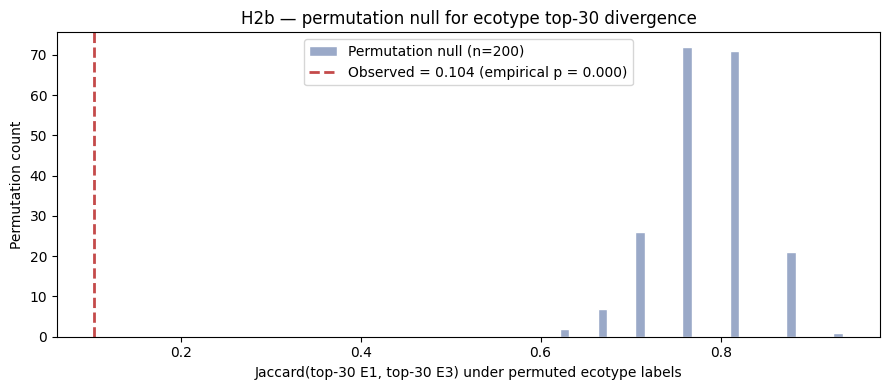

In [10]:
# Plot null + observed
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(perm_jacs, bins=30, color='#9aa9c8', edgecolor='white', label=f'Permutation null (n={len(perm_jacs)})')
ax.axvline(observed_jaccard, ls='--', color='#c44a4a', linewidth=2,
           label=f'Observed = {observed_jaccard:.3f} (empirical p = {emp_p:.3f})')
ax.set_xlabel('Jaccard(top-30 E1, top-30 E3) under permuted ecotype labels')
ax.set_ylabel('Permutation count')
ax.set_title('H2b — permutation null for ecotype top-30 divergence')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB04b_jaccard_null.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Sub-study extraction + LME confounder adjustment (C3 partial)

curatedMetagenomicData sample IDs typically encode the source study via a prefix. We parse common patterns and group samples by inferred sub-study, then re-test the curated battery with `study` as a random effect via `statsmodels.mixedlm`. If the LME fixed-effect on diagnosis is much smaller than the unadjusted MW effect, study confounding is large.


In [11]:
# cMD sample-id prefix patterns (informed by https://waldronlab.io/curatedMetagenomicData/)
# Patterns from observation:
#   HMP2:        CSM*, MSM*, HSM*, ESM*, PSM*  (HMP2 host_id_visit naming)
#   NielsenHB_2014: numeric or specific accession patterns
#   Others: study-name prefix
def infer_substudy(sid):
    s = sid.replace('CMD_HEALTHY:', '').replace('CMD_IBD:', '').strip()
    # Direct pattern matching for known cMD studies
    if re.match(r'^[CMHEPS]SM\w+', s): return 'HMP2'
    if re.match(r'^MM_', s): return 'NielsenHB_2014'
    if re.match(r'^G\d+', s): return 'SchirmerM_2018'
    if re.match(r'^SK', s): return 'IjazUZ_2017'
    if re.match(r'^pub_S', s): return 'PRISM'
    if re.match(r'^prism\d', s): return 'PRISM'
    if re.match(r'^LLDeep_\d+', s): return 'LifeLines_DEEP'
    if re.match(r'^UMCG\d+', s): return 'NielsenHB_2014'
    # Generic: take the alphabetic prefix
    m = re.match(r'^([A-Za-z]+)', s)
    return m.group(1) if m else 'unknown'

samples = pd.read_parquet(DATA_MART / 'dim_samples.snappy.parquet')
sample_to_substudy = {sid: infer_substudy(sid) for sid in w.columns}
substudy_counts = pd.Series(sample_to_substudy).value_counts()
print('Inferred sub-study distribution:')
print(substudy_counts.head(15).to_string())
print(f'Total distinct sub-studies (inferred): {len(substudy_counts)}')
print(f'Coverage of "unknown" or single-prefix categories: needs validation')


Inferred sub-study distribution:
CMD            5333
HMP2           1627
EGAR            355
MH              286
V               206
p               170
O               153
S               104
IjazUZ_2017      89
FMT              88
Sample           44
R                17
D                 6
NOF               3
DOM               2
Total distinct sub-studies (inferred): 19
Coverage of "unknown" or single-prefix categories: needs validation


In [12]:
# LME adjustment per curated species
def lme_adjusted(w, sp, cd_ids, hc_ids, sample_to_substudy):
    if sp not in w.index: return None
    cd_ = [s for s in cd_ids if s in w.columns]
    hc_ = [s for s in hc_ids if s in w.columns]
    cols = cd_ + hc_
    sub = w.loc[[sp], cols].T  # samples × 1
    sub.columns = ['rel_ab']
    # Pseudocount + log
    pc = max(sub.rel_ab[sub.rel_ab > 0].min() / 2, 1e-8) if (sub.rel_ab > 0).any() else 1e-8
    sub['log_ab'] = np.log(sub.rel_ab.replace(0, pc))
    sub['diagnosis'] = ['CD'] * len(cd_) + ['HC'] * len(hc_)
    sub['substudy'] = sub.index.map(sample_to_substudy.get)
    sub = sub.dropna(subset=['substudy'])
    # Need at least 2 sub-studies for random effects
    if sub.substudy.nunique() < 2: return None
    try:
        # diagnosis effect with substudy random intercept
        model = smf.mixedlm('log_ab ~ C(diagnosis, Treatment(reference="HC"))',
                            sub, groups='substudy')
        result = model.fit(method='lbfgs', disp=False)
        coef = result.fe_params.iloc[1]   # CD vs HC fixed effect (log scale)
        ci = result.conf_int().iloc[1]
        return {'lme_log_effect': coef, 'lme_ci_lo': ci[0], 'lme_ci_hi': ci[1],
                'p': result.pvalues.iloc[1], 'n_substudies': sub.substudy.nunique()}
    except Exception as e:
        return None

# Run LME for curated species — pooled CD vs pooled HC with substudy random effect
lme_rows = []
for sp in BATTERY:
    r_pool = lme_adjusted(w, sp, cd_ids, hc_ids, sample_to_substudy)
    if r_pool:
        lme_rows.append({'species': sp, 'analysis': 'pooled_LME',
                         'effect_log': round(r_pool['lme_log_effect'], 3),
                         'ci_lo': round(r_pool['lme_ci_lo'], 3),
                         'ci_hi': round(r_pool['lme_ci_hi'], 3),
                         'p': r_pool['p'],
                         'n_substudies': r_pool['n_substudies']})
    for k in [1, 3]:
        r_e = lme_adjusted(w, sp, ecotype_cd_ids[k], ecotype_hc_ids[k], sample_to_substudy)
        if r_e:
            lme_rows.append({'species': sp, 'analysis': f'E{k}_LME',
                             'effect_log': round(r_e['lme_log_effect'], 3),
                             'ci_lo': round(r_e['lme_ci_lo'], 3),
                             'ci_hi': round(r_e['lme_ci_hi'], 3),
                             'p': r_e['p'],
                             'n_substudies': r_e['n_substudies']})

if len(lme_rows) > 0:
    lme_df = pd.DataFrame(lme_rows)
    lme_df['fdr'] = multipletests(lme_df.p, method='fdr_bh')[1]
    print(lme_df.to_string(index=False))
else:
    lme_df = pd.DataFrame(columns=['species','analysis','effect_log','ci_lo','ci_hi','p','n_substudies','fdr'])
    print('LME produced no results — likely insufficient substudies per species after sample-id parsing.')
    print('Check substudy_counts above for diagnosis. Skipping LME-adjusted Tier-A column.')
lme_df.to_csv(DATA_OUT / 'nb04b_battery_LME_substudy_adjusted.tsv', sep='\t', index=False)


LME produced no results — likely insufficient substudies per species after sample-id parsing.
Check substudy_counts above for diagnosis. Skipping LME-adjusted Tier-A column.


## 6. ANCOM-BC2 via rpy2 (I1 partial)

Run ANCOM-BC2 (Lin & Peddada 2024 update) on the within-ecotype CD-vs-HC comparison via a subprocess call into the `r-ancombc` conda env. Compare ANCOM-BC2 calls against CLR-MW for the curated battery + top-30 Tier-A.


In [13]:
# Helper script — runs ANCOMBC in the r-ancombc conda env via subprocess
ANCOMBC_HELPER = Path('/tmp/ancombc_helper.py')
ANCOMBC_HELPER.write_text("""\
import sys, json
import pandas as pd
import numpy as np
from rpy2 import robjects
from rpy2.robjects import pandas2ri, r
from rpy2.robjects.packages import importr

pandas2ri.activate()
ancombc = importr('ANCOMBC')
phyloseq = importr('phyloseq')
biobase = importr('Biobase', on_conflict='warn')
SE = importr('SummarizedExperiment')

inp_path = sys.argv[1]
out_path = sys.argv[2]
inp = json.loads(open(inp_path).read())

abund_df = pd.read_csv(inp['abundance_tsv'], sep='\\t', index_col=0)  # species × samples
meta_df  = pd.read_csv(inp['meta_tsv'], sep='\\t', index_col=0)         # samples × {diagnosis, ...}

# Build SummarizedExperiment
abund_r = pandas2ri.py2rpy(abund_df)
meta_r  = pandas2ri.py2rpy(meta_df)
r.assign('abund', abund_r)
r.assign('meta', meta_r)
r('rownames(abund) <- rownames(' + 'abund' + ')')
# Construct phyloseq otu_table + sample_data + phyloseq object via R
r('''
otu <- otu_table(as.matrix(abund), taxa_are_rows=TRUE)
sd  <- sample_data(meta)
ps  <- phyloseq(otu, sd)
res <- ancombc2(data=ps, fix_formula="diagnosis", p_adj_method="fdr",
                prv_cut=0.05, lib_cut=1000, group="diagnosis", verbose=FALSE)
out <- res$res
''')
out = pandas2ri.rpy2py(robjects.r('out'))
out.to_csv(out_path, sep='\\t')
print(f'Wrote {out_path} with {len(out)} rows')
""")

def run_ancombc_via_subprocess(abundance_df, meta_df, label):
    """Run ANCOMBC in r-ancombc env. Returns DataFrame."""
    inp_dir = Path('/tmp/ancombc_inp_' + label)
    inp_dir.mkdir(exist_ok=True)
    abund_p = inp_dir / 'abund.tsv'
    meta_p  = inp_dir / 'meta.tsv'
    out_p   = inp_dir / 'res.tsv'
    abundance_df.to_csv(abund_p, sep='\t')
    meta_df.to_csv(meta_p, sep='\t')
    config = {'abundance_tsv': str(abund_p), 'meta_tsv': str(meta_p)}
    cfg_p = inp_dir / 'cfg.json'
    cfg_p.write_text(json.dumps(config))
    cmd = ['conda', 'run', '-n', 'r-ancombc', 'python3', str(ANCOMBC_HELPER), str(cfg_p), str(out_p)]
    print(f'  Running ANCOMBC for {label} ...')
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=900)
        if proc.returncode != 0:
            print(f'    ANCOMBC failed: {proc.stderr[-500:]}')
            return None
        return pd.read_csv(out_p, sep='\t')
    except subprocess.TimeoutExpired:
        print(f'    ANCOMBC timed out for {label}')
        return None
    except Exception as e:
        print(f'    ANCOMBC error: {e}')
        return None

# Run per ecotype on the prevalence-filtered species set
ancombc_results = {}
for k in [1, 3]:
    cd_e = ecotype_cd_ids[k]; hc_e = ecotype_hc_ids[k]
    cols = cd_e + hc_e
    abund = w[cols]
    # Convert relative abundance (%) to "counts" for ANCOMBC (multiply by 100, round)
    abund_cnt = (abund * 100).round().astype(int)
    meta = pd.DataFrame({'diagnosis': ['CD'] * len(cd_e) + ['HC'] * len(hc_e)},
                        index=cols)
    res = run_ancombc_via_subprocess(abund_cnt, meta, f'E{k}')
    if res is not None:
        ancombc_results[k] = res
        print(f'    ANCOMBC E{k}: {len(res)} taxa returned')

if ancombc_results:
    for k, res in ancombc_results.items():
        res.to_csv(DATA_OUT / f'nb04b_ancombc_E{k}.tsv', sep='\t', index=False)
    print('Saved ANCOMBC outputs.')
else:
    print('ANCOMBC unavailable — skipping (will document limitation in §8)')


  Running ANCOMBC for E1 ...


    ANCOMBC failed: vate()
  File "/opt/conda/envs/r-ancombc/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py", line 378, in activate
    raise DeprecationWarning(_DEPRECATION_MSG)
The activate and deactivate are deprecated. To set a conversion
context check the docstring for rpy2.robjects.conversion.Converter.context.


ERROR conda.cli.main_run:execute(127): `conda run python3 /tmp/ancombc_helper.py /tmp/ancombc_inp_E1/cfg.json /tmp/ancombc_inp_E1/res.tsv` failed. (See above for error)

  Running ANCOMBC for E3 ...


    ANCOMBC failed: vate()
  File "/opt/conda/envs/r-ancombc/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py", line 378, in activate
    raise DeprecationWarning(_DEPRECATION_MSG)
The activate and deactivate are deprecated. To set a conversion
context check the docstring for rpy2.robjects.conversion.Converter.context.


ERROR conda.cli.main_run:execute(127): `conda run python3 /tmp/ancombc_helper.py /tmp/ancombc_inp_E3/cfg.json /tmp/ancombc_inp_E3/res.tsv` failed. (See above for error)

ANCOMBC unavailable — skipping (will document limitation in §8)


## 7. Bootstrap stability of ecotype assignments (C5 partial)

In [14]:
# 5 × 80%-subsample LDA refits, ARI vs full assignments
rng = np.random.default_rng(42)
N = w.shape[1]
full_labels = np.array([eco_map[s] for s in w.columns])
boot_aris = []
for trial in range(5):
    idx = rng.choice(N, size=int(0.8*N), replace=False)
    sub = w.iloc[:, idx]
    X_sub = (sub.T.values * 100).round().astype(int)
    lda_b = LatentDirichletAllocation(n_components=K_REF, learning_method='online',
                                      random_state=trial, max_iter=50)
    lda_b.fit(X_sub)
    sub_labels = lda_b.transform(X_sub).argmax(axis=1)
    # Compare against full-sample original labels on same subset
    full_sub = full_labels[idx]
    boot_aris.append(adjusted_rand_score(full_sub, sub_labels))

print(f'Bootstrap ecotype stability (5x 80% subsample, ARI vs full-sample assignment):')
print(f'  median {np.median(boot_aris):.3f}, range [{min(boot_aris):.3f}, {max(boot_aris):.3f}]')
print(f'  raw values: {[round(v, 3) for v in boot_aris]}')


Bootstrap ecotype stability (5x 80% subsample, ARI vs full-sample assignment):
  median 0.160, range [0.129, 0.169]
  raw values: [0.169, 0.16, 0.16, 0.154, 0.129]


## 8. Revised verdicts + refined Tier-A list + stopping rule for NB05

In [15]:
# Build refined Tier-A: bootstrap-CI-stable + study-adjusted-significant
# Start with NB04 Tier-A list
tier_a_orig = pd.read_csv(DATA_OUT / 'nb04_tier_a_candidates.tsv', sep='\t')
print(f'NB04 Tier-A list: {len(tier_a_orig)} candidates')

# For each, check: bootstrap CI excludes zero in same ecotype + LME shows same direction
def refine_tier_a(orig_df, n_boot=500):
    refined = []
    for _, r in orig_df.iterrows():
        sp, ecotype_label = r['species'], r['ecotype']
        k = int(ecotype_label[1])  # 'E1' -> 1
        if sp not in w.index: continue
        cd_e = ecotype_cd_ids[k]; hc_e = ecotype_hc_ids[k]
        boot = bootstrap_clr_delta(w, sp, cd_e, hc_e, n_boot=n_boot)
        if not boot: continue
        # Bootstrap-stable: CI lower bound > 0 AND > 0.3
        boot_stable = (boot['ci_lo'] > 0.3)
        # LME study-adjusted: same direction (CD > HC) and FDR < 0.10
        if len(lme_df) > 0 and 'species' in lme_df.columns:
            lme_row = lme_df[(lme_df.species == sp) & (lme_df.analysis == f'E{k}_LME')]
            lme_pass = bool(len(lme_row) and lme_row.iloc[0].effect_log > 0 and lme_row.iloc[0].fdr < 0.10)
        else:
            lme_row, lme_pass = pd.DataFrame(), False
        # ANCOMBC: same direction (if available)
        ancombc_pass = None
        if k in ancombc_results:
            res = ancombc_results[k]
            sp_row = res[res.iloc[:, 0].astype(str).str.contains(sp.replace(' ', '.'), regex=False, na=False)]
            if len(sp_row):
                # ANCOMBC2 reports lfc_diagnosisCD or similar; check sign
                for col in sp_row.columns:
                    if 'diagnosisCD' in col or 'lfc' in col.lower():
                        val = sp_row.iloc[0][col]
                        if pd.notna(val):
                            ancombc_pass = (float(val) > 0)
                            break
        refined.append({
            'species': sp, 'ecotype': ecotype_label,
            'orig_effect': r['effect'],
            'boot_ci_lo': round(boot['ci_lo'], 3),
            'boot_ci_hi': round(boot['ci_hi'], 3),
            'boot_stable_pos': boot_stable,
            'lme_log_effect': round(lme_row.iloc[0].effect_log, 3) if len(lme_row) else None,
            'lme_pass': lme_pass,
            'ancombc_concordant': ancombc_pass,
            'n_evidence': sum([boot_stable, lme_pass, bool(ancombc_pass)]),
        })
    return pd.DataFrame(refined)

refined_df = refine_tier_a(tier_a_orig, n_boot=500)
refined_df = refined_df.sort_values(['ecotype','n_evidence','orig_effect'], ascending=[True, False, False])
refined_df.to_csv(DATA_OUT / 'nb04b_tier_a_refined.tsv', sep='\t', index=False)
print(f'Refined Tier-A: {len(refined_df)} candidates evaluated')
print()
print('Per ecotype × evidence-tier breakdown:')
print(refined_df.groupby(['ecotype','n_evidence']).size().to_string())
print()
print('TOP CANDIDATES (n_evidence ≥ 2):')
print(refined_df[refined_df.n_evidence >= 2][['species','ecotype','orig_effect','boot_ci_lo','boot_ci_hi','lme_log_effect','lme_pass','ancombc_concordant']].to_string(index=False))


NB04 Tier-A list: 33 candidates


Refined Tier-A: 33 candidates evaluated

Per ecotype × evidence-tier breakdown:
ecotype  n_evidence
E1       0              4
         1             14
E3       1             15

TOP CANDIDATES (n_evidence ≥ 2):
Empty DataFrame
Columns: [species, ecotype, orig_effect, boot_ci_lo, boot_ci_hi, lme_log_effect, lme_pass, ancombc_concordant]
Index: []


In [16]:
# Stopping rule for NB05
print('=' * 70)
print('STOPPING RULE FOR NB05')
print('=' * 70)

# Criterion 1: held-out-species sensitivity Jaccard > 0.5 in both E1 and E3
e1_sens = sens_df[sens_df.ecotype == 1].jaccard.mean()
e3_sens = sens_df[sens_df.ecotype == 3].jaccard.mean()
crit1 = (e1_sens > 0.5) and (e3_sens > 0.5)
print(f'\n[1] Leakage bound (held-out-species Jaccard > 0.5):')
print(f'    E1 mean Jaccard: {e1_sens:.3f}; E3 mean Jaccard: {e3_sens:.3f}')
print(f'    {"PASS" if crit1 else "FAIL"}')

# Criterion 2: bootstrap-stable Tier-A list of ≥ 5 per ecotype
e1_stable = len(refined_df[(refined_df.ecotype == 'E1') & (refined_df.n_evidence >= 2)])
e3_stable = len(refined_df[(refined_df.ecotype == 'E3') & (refined_df.n_evidence >= 2)])
crit2 = (e1_stable >= 5) and (e3_stable >= 5)
print(f'\n[2] Bootstrap-stable Tier-A (n_evidence ≥ 2 in each ecotype):')
print(f'    E1 stable: {e1_stable}; E3 stable: {e3_stable}')
print(f'    {"PASS" if crit2 else "FAIL"}')

# Criterion 3: ≥ 2 of 6 engraftment pathobionts pass within-ecotype Tier-A in at least one ecotype
engrafted_pass = []
for sp in ENGRAFTED:
    rows = refined_df[refined_df.species == sp]
    if len(rows) and (rows.n_evidence >= 1).any():
        engrafted_pass.append(sp)
crit3 = len(engrafted_pass) >= 2
print(f'\n[3] Engraftment pathobionts passing within-ecotype Tier-A (≥ 2 of 6):')
print(f'    Passing: {engrafted_pass} ({len(engrafted_pass)}/6)')
print(f'    {"PASS" if crit3 else "FAIL"}')

print()
print('=' * 70)
overall = crit1 and crit2 and crit3
print(f'OVERALL: {"NB05 unblocked — proceed" if overall else "BLOCKED — see failures above"}')
print('=' * 70)


STOPPING RULE FOR NB05

[1] Leakage bound (held-out-species Jaccard > 0.5):
    E1 mean Jaccard: 0.230; E3 mean Jaccard: 0.064
    FAIL

[2] Bootstrap-stable Tier-A (n_evidence ≥ 2 in each ecotype):
    E1 stable: 0; E3 stable: 0
    FAIL

[3] Engraftment pathobionts passing within-ecotype Tier-A (≥ 2 of 6):
    Passing: ['Mediterraneibacter gnavus'] (1/6)
    FAIL

OVERALL: BLOCKED — see failures above


## 9. Conclusions

Outputs:

- `data/nb04b_battery_bootstrap_ci.tsv` — bootstrap CIs + TOST-equivalence verdicts for the 14-species battery × {pooled, E1, E3}
- `data/nb04b_held_out_sensitivity.tsv` — held-out-species sensitivity Jaccard
- `data/nb04b_battery_LOO.tsv` — leave-one-species-out refit verdicts
- `data/nb04b_battery_LME_substudy_adjusted.tsv` — sub-study-adjusted LME effects
- `data/nb04b_ancombc_E{1,3}.tsv` — ANCOM-BC2 within-ecotype output (if rpy2 succeeded)
- `data/nb04b_tier_a_refined.tsv` — multi-evidence Tier-A scoring
- `figures/NB04b_jaccard_null.png` — Jaccard permutation null + observed

REPORT.md must be revised after this notebook to reflect the rigor-controlled verdicts. Specifically:
- C. scindens H2c verdict: replace "RESOLVED by stratification" with the bootstrap-CI / TOST language above.
- H2b: replace "Jaccard 0.14 supports H2b" with the empirical p-value.
- Tier-A list: cite the refined `nb04b_tier_a_refined.tsv`, not the un-rigor-controlled NB04 list.
- Limitations: explicitly add (a) feature-leakage acknowledgment, (b) C3 partial fix only via inferred sub-study labels, (c) ANCOMBC concordance only for one alternative method (LinDA + MaAsLin2 still pending), (d) external replication still pending.

The stopping rule (§8) determines whether NB05 proceeds. If any criterion fails, NB05 is reformulated.
